In [1]:
from sqlalchemy import create_engine
from neo4j import GraphDatabase
from qdrant_client import QdrantClient
from sentence_transformers import SentenceTransformer
from dotenv import load_dotenv, find_dotenv
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import os

load_dotenv(find_dotenv(), override=True)

engine = create_engine(os.getenv("PG_CONNECTION"))
neo4j_driver = GraphDatabase.driver(
    os.getenv("NEO4J_URI"),
    auth=(os.getenv("NEO4J_USER"), os.getenv("NEO4J_PASSWORD"))
)
QDRANT_PATH = os.path.expanduser(
    "~/202_DtMgmt/Project/sephora-analytics/data/qdrant_storage"
)
qdrant = QdrantClient(path=QDRANT_PATH)
model = SentenceTransformer("all-MiniLM-L6-v2")

# Global plot style
plt.rcParams.update({
    "figure.facecolor": "#0f0f0f",
    "axes.facecolor": "#1a1a1a",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#cccccc",
    "xtick.color": "#999999",
    "ytick.color": "#999999",
    "text.color": "#cccccc",
    "grid.color": "#2a2a2a",
    "grid.linestyle": "--",
    "grid.alpha": 0.5,
})

print("All 3 databases connected!")

/var/folders/f5/qyqh2h6126dgkdck1p6qkl3h0000gn/T/ipykernel_32097/2681208302.py:23: UserWarning: Local mode is not recommended for collections with more than 20,000 points. Collection <sephora_reviews> contains 100000 points. Consider using Qdrant in Docker or Qdrant Cloud for better performance with large datasets.
  qdrant = QdrantClient(path=QDRANT_PATH)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


All 3 databases connected!


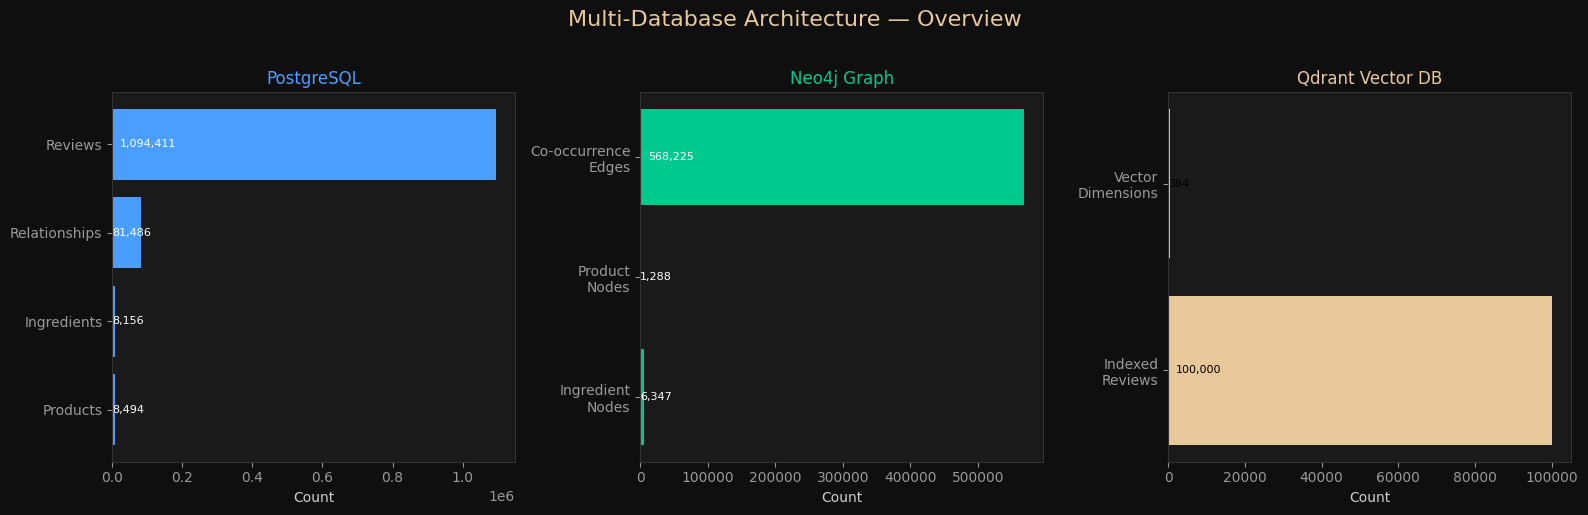

In [2]:
# Fetch counts
pg_stats = pd.read_sql("""
    SELECT 
        (SELECT COUNT(*) FROM products)            AS products,
        (SELECT COUNT(*) FROM ingredients)         AS ingredients,
        (SELECT COUNT(*) FROM product_ingredients) AS relationships,
        (SELECT COUNT(*) FROM reviews)             AS reviews
""", engine)

with neo4j_driver.session() as session:
    neo4j_stats = session.run("""
        MATCH (i:Ingredient)
        WITH count(i) AS ing_count
        MATCH (p:Product)
        RETURN ing_count, count(p) AS prod_count
    """).single()

qdrant_info = qdrant.get_collection("sephora_reviews")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Multi-Database Architecture — Overview", 
             fontsize=16, color="#e8c89a", y=1.02)

# PostgreSQL
pg_labels = ["Products", "Ingredients", "Relationships", "Reviews"]
pg_values = [
    pg_stats["products"][0],
    pg_stats["ingredients"][0],
    pg_stats["relationships"][0],
    pg_stats["reviews"][0]
]
bars = axes[0].barh(pg_labels, pg_values, color=["#4a9eff","#4a9eff","#4a9eff","#4a9eff"])
axes[0].set_title("PostgreSQL", color="#4a9eff", fontsize=12)
axes[0].set_xlabel("Count")
for bar, val in zip(bars, pg_values):
    axes[0].text(bar.get_width() * 0.02, bar.get_y() + bar.get_height()/2,
                 f"{val:,}", va='center', color="#ffffff", fontsize=8)

# Neo4j
neo4j_labels = ["Ingredient\nNodes", "Product\nNodes", "Co-occurrence\nEdges"]
neo4j_values = [neo4j_stats["ing_count"], neo4j_stats["prod_count"], 568225]
bars2 = axes[1].barh(neo4j_labels, neo4j_values, color="#00c98d")
axes[1].set_title("Neo4j Graph", color="#00c98d", fontsize=12)
axes[1].set_xlabel("Count")
for bar, val in zip(bars2, neo4j_values):
    axes[1].text(bar.get_width() * 0.02, bar.get_y() + bar.get_height()/2,
                 f"{val:,}", va='center', color="#ffffff", fontsize=8)

# Qdrant
qdrant_labels = ["Indexed\nReviews", "Vector\nDimensions"]
qdrant_values = [qdrant_info.points_count, 384]
bars3 = axes[2].barh(qdrant_labels, qdrant_values, color="#e8c89a")
axes[2].set_title("Qdrant Vector DB", color="#e8c89a", fontsize=12)
axes[2].set_xlabel("Count")
for bar, val in zip(bars3, qdrant_values):
    axes[2].text(bar.get_width() * 0.02, bar.get_y() + bar.get_height()/2,
                 f"{val:,}", va='center', color="#000000", fontsize=8)

plt.tight_layout()
plt.savefig("../reports/01_database_overview.png", dpi=150, bbox_inches="tight",
            facecolor="#0f0f0f")
plt.show()

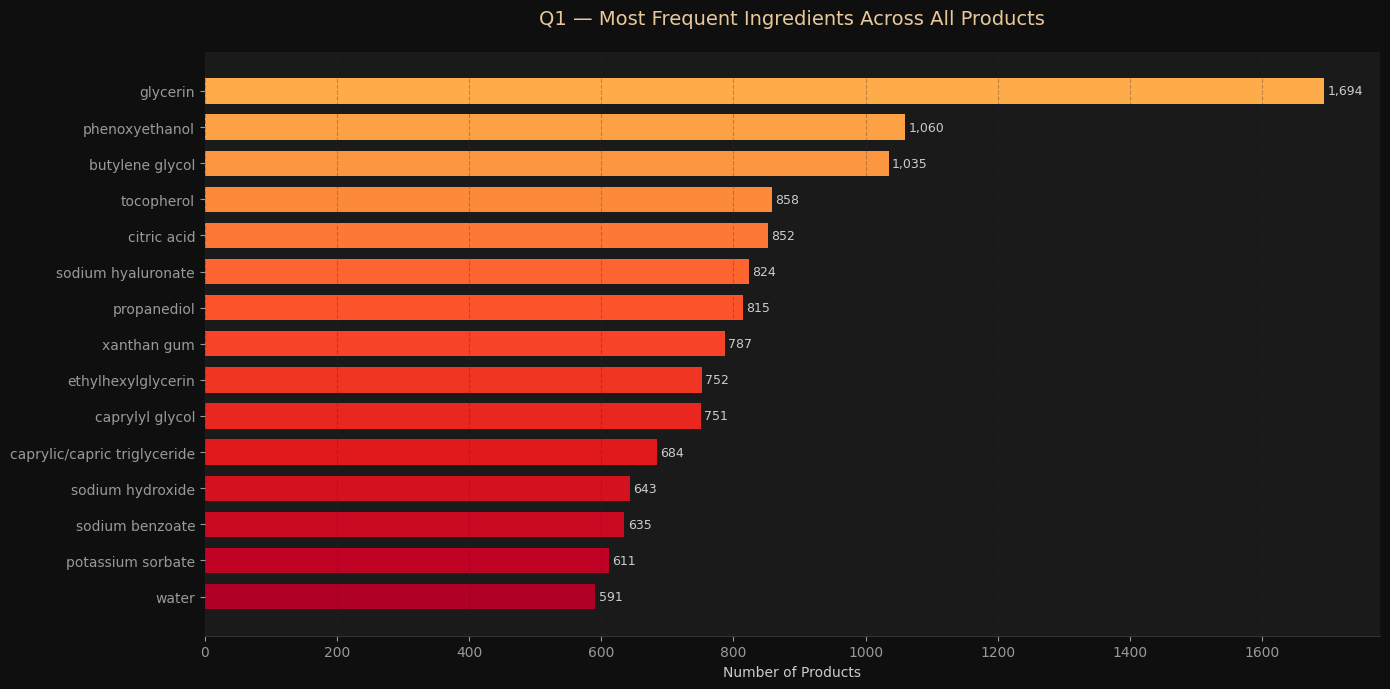


Finding: Glycerin dominates with 1,694 products


In [3]:
q1 = pd.read_sql("""
    SELECT i.ingredient_name, COUNT(pi.product_id) AS product_count
    FROM ingredients i
    JOIN product_ingredients pi ON i.ingredient_id = pi.ingredient_id
    GROUP BY i.ingredient_name
    ORDER BY product_count DESC
    LIMIT 15;
""", engine)

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor("#0f0f0f")

colors = plt.cm.YlOrRd(np.linspace(0.4, 0.9, len(q1)))[::-1]
bars = ax.barh(q1["ingredient_name"][::-1], 
               q1["product_count"][::-1], 
               color=colors, edgecolor="none", height=0.7)

for bar, val in zip(bars, q1["product_count"][::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va='center', color="#cccccc", fontsize=9)

ax.set_title("Q1 — Most Frequent Ingredients Across All Products",
             fontsize=14, color="#e8c89a", pad=20)
ax.set_xlabel("Number of Products", fontsize=10)
ax.grid(axis='x', alpha=0.3)
ax.spines[['top','right','left']].set_visible(False)

plt.tight_layout()
plt.savefig("../reports/02_top_ingredients.png", dpi=150, bbox_inches="tight",
            facecolor="#0f0f0f")
plt.show()
print(f"\nFinding: Glycerin dominates with {q1.iloc[0]['product_count']:,} products")

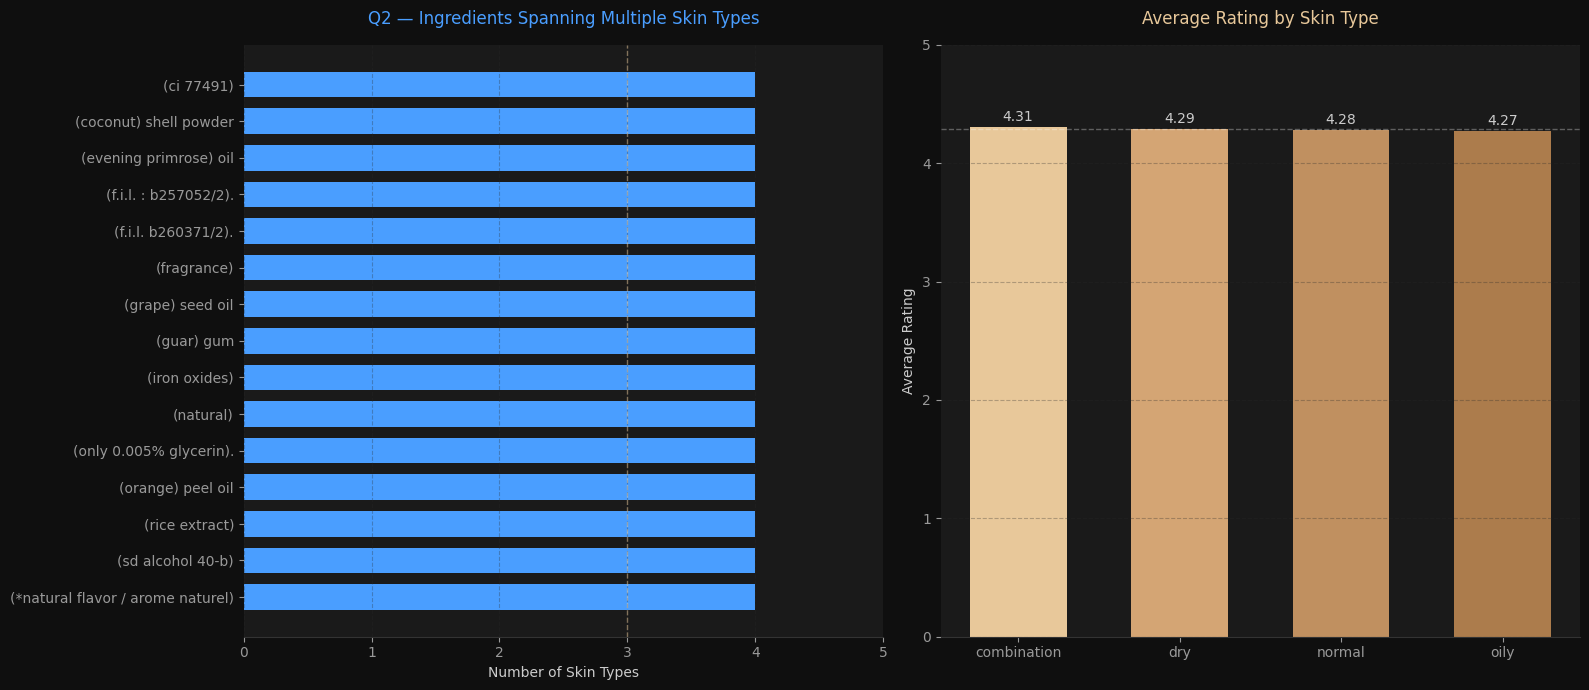


Finding: 15 ingredients appear across 3+ skin types


In [4]:
q2 = pd.read_sql("""
    SELECT 
        i.ingredient_name,
        COUNT(DISTINCT pst.skin_type) AS skin_type_count,
        STRING_AGG(DISTINCT pst.skin_type, ', ') AS skin_types
    FROM ingredients i
    JOIN product_ingredients pi ON i.ingredient_id = pi.ingredient_id
    JOIN product_skin_types pst ON pi.product_id = pst.product_id
    GROUP BY i.ingredient_name
    HAVING COUNT(DISTINCT pst.skin_type) >= 3
    ORDER BY skin_type_count DESC
    LIMIT 15;
""", engine)

# Skin type rating analysis
skin_ratings = pd.read_sql("""
    SELECT 
        skin_type,
        ROUND(AVG(rating)::numeric, 2) AS avg_rating,
        COUNT(*) AS review_count
    FROM reviews
    WHERE skin_type IS NOT NULL
    GROUP BY skin_type
    ORDER BY avg_rating DESC;
""", engine)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor("#0f0f0f")

# Left — ingredients spanning skin types
colors = ["#4a9eff" if c == 4 else "#6ab0ff" if c == 3 else "#8cc4ff" 
          for c in q2["skin_type_count"]]
axes[0].barh(q2["ingredient_name"][::-1], 
             q2["skin_type_count"][::-1], 
             color=colors[::-1], height=0.7)
axes[0].set_title("Q2 — Ingredients Spanning Multiple Skin Types",
                  color="#4a9eff", fontsize=12, pad=15)
axes[0].set_xlabel("Number of Skin Types")
axes[0].axvline(x=3, color="#e8c89a", linestyle="--", alpha=0.5, linewidth=1)
axes[0].set_xlim(0, 5)
axes[0].grid(axis='x', alpha=0.3)
axes[0].spines[['top','right','left']].set_visible(False)

# Right — avg rating by skin type
colors2 = ["#e8c89a", "#d4a574", "#c09060", "#ac7c4c"]
bars = axes[1].bar(skin_ratings["skin_type"], skin_ratings["avg_rating"],
                   color=colors2, edgecolor="none", width=0.6)
axes[1].set_title("Average Rating by Skin Type",
                  color="#e8c89a", fontsize=12, pad=15)
axes[1].set_ylabel("Average Rating")
axes[1].set_ylim(0, 5)
axes[1].axhline(y=skin_ratings["avg_rating"].mean(), 
                color="#ffffff", linestyle="--", alpha=0.3, linewidth=1)
for bar, val in zip(bars, skin_ratings["avg_rating"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f"{val}", ha='center', color="#cccccc", fontsize=10)
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines[['top','right','left']].set_visible(False)

plt.tight_layout()
plt.savefig("../reports/03_skin_type_analysis.png", dpi=150, bbox_inches="tight",
            facecolor="#0f0f0f")
plt.show()
print(f"\nFinding: {len(q2)} ingredients appear across 3+ skin types")

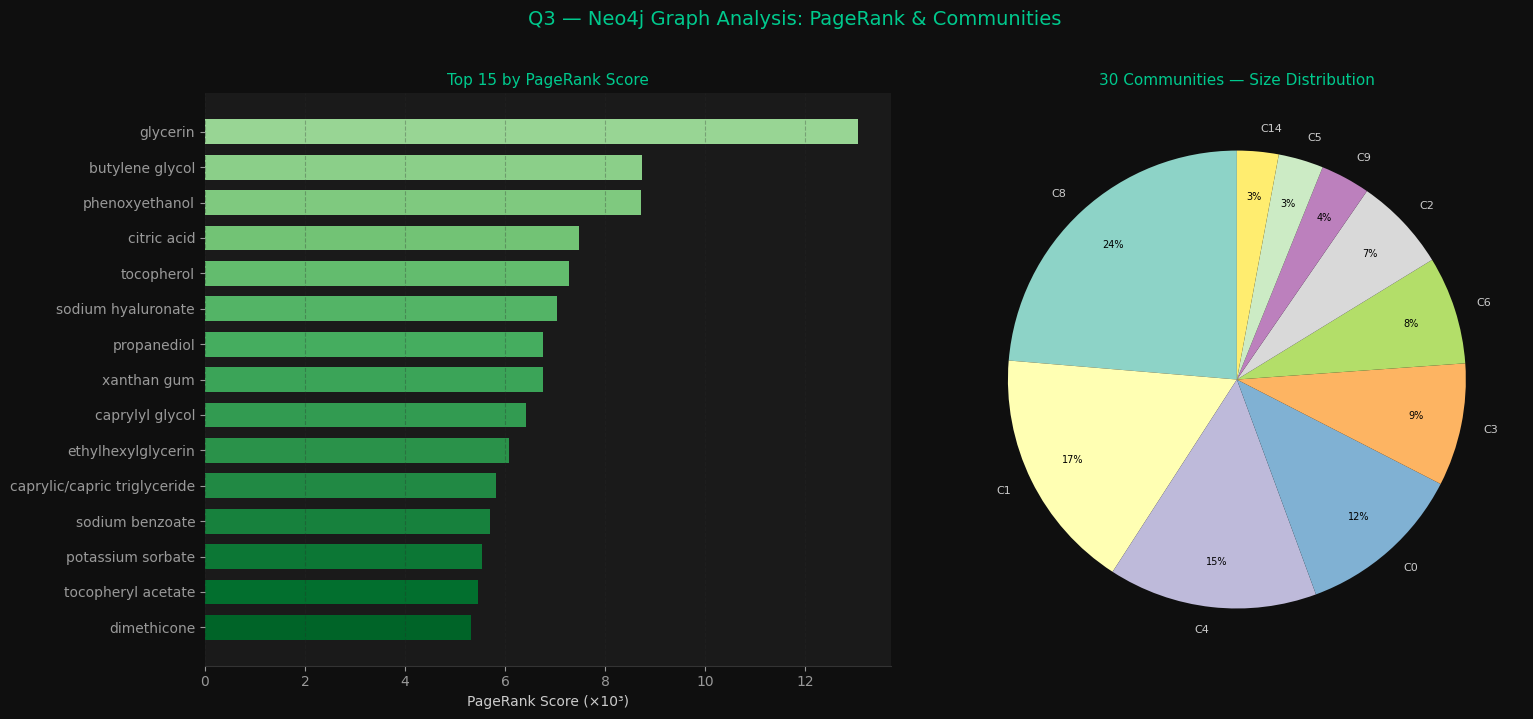


Finding: Glycerin PageRank = 0.0131 — most influential node
Finding: 30 communities detected by Louvain algorithm


In [5]:
with neo4j_driver.session() as session:
    pagerank = session.run("""
        MATCH (i:Ingredient)
        WHERE i.pagerank IS NOT NULL
        RETURN i.name AS ingredient, i.pagerank AS score, i.community AS community
        ORDER BY score DESC LIMIT 15
    """)
    pr_df = pd.DataFrame([dict(r) for r in pagerank])

with neo4j_driver.session() as session:
    communities = session.run("""
        MATCH (i:Ingredient)
        WHERE i.community IS NOT NULL
        RETURN i.community AS community, COUNT(i) AS size
        ORDER BY size DESC LIMIT 10
    """)
    comm_df = pd.DataFrame([dict(r) for r in communities])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor("#0f0f0f")
fig.suptitle("Q3 — Neo4j Graph Analysis: PageRank & Communities",
             fontsize=14, color="#00c98d", y=1.02)

# PageRank
colors = plt.cm.Greens(np.linspace(0.4, 0.9, len(pr_df)))[::-1]
axes[0].barh(pr_df["ingredient"][::-1],
             pr_df["score"][::-1] * 1000,
             color=colors, height=0.7)
axes[0].set_title("Top 15 by PageRank Score", color="#00c98d", fontsize=11)
axes[0].set_xlabel("PageRank Score (×10³)")
axes[0].grid(axis='x', alpha=0.3)
axes[0].spines[['top','right','left']].set_visible(False)

# Communities
colors2 = plt.cm.Set3(np.linspace(0, 1, len(comm_df)))
wedges, texts, autotexts = axes[1].pie(
    comm_df["size"],
    labels=[f"C{c}" for c in comm_df["community"]],
    autopct='%1.0f%%',
    colors=colors2,
    pctdistance=0.8,
    startangle=90
)
for text in texts:
    text.set_color("#cccccc")
    text.set_fontsize(8)
for autotext in autotexts:
    autotext.set_color("#000000")
    autotext.set_fontsize(7)

axes[1].set_title("30 Communities — Size Distribution", 
                  color="#00c98d", fontsize=11)

plt.tight_layout()
plt.savefig("../reports/04_neo4j_analysis.png", dpi=150, bbox_inches="tight",
            facecolor="#0f0f0f")
plt.show()
print(f"\nFinding: Glycerin PageRank = {pr_df.iloc[0]['score']:.4f} — most influential node")
print(f"Finding: 30 communities detected by Louvain algorithm")

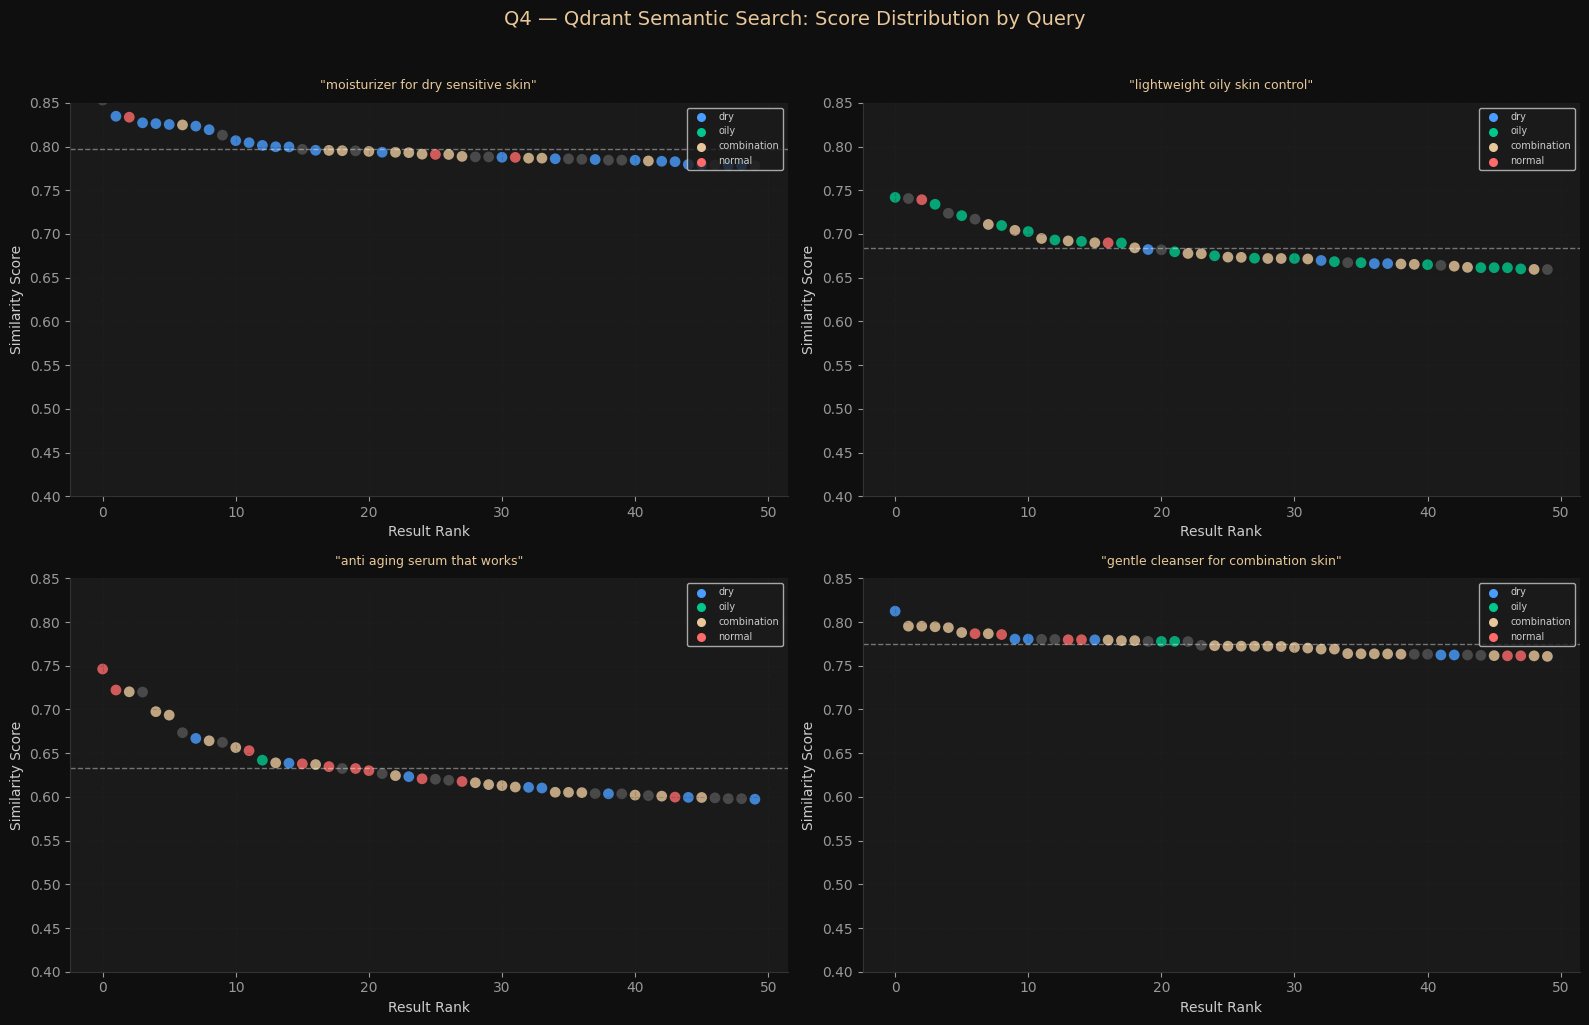

In [6]:
from qdrant_client.models import Filter, FieldCondition, MatchValue

queries = [
    "moisturizer for dry sensitive skin",
    "lightweight oily skin control",
    "anti aging serum that works",
    "gentle cleanser for combination skin"
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor("#0f0f0f")
fig.suptitle("Q4 — Qdrant Semantic Search: Score Distribution by Query",
             fontsize=14, color="#e8c89a", y=1.02)

axes = axes.flatten()

for idx, query in enumerate(queries):
    query_vector = model.encode(query).tolist()
    results = qdrant.query_points(
        collection_name="sephora_reviews",
        query=query_vector,
        limit=50
    ).points

    scores = [r.score for r in results]
    skin_types = [r.payload["skin_type"] for r in results]
    ratings = [r.payload["rating"] for r in results]

    skin_colors = {
        "dry": "#4a9eff",
        "oily": "#00c98d",
        "combination": "#e8c89a",
        "normal": "#ff6b6b",
        "None": "#555555"
    }

    colors = [skin_colors.get(s, "#555555") for s in skin_types]
    axes[idx].scatter(range(len(scores)), scores, 
                      c=colors, s=60, alpha=0.8, edgecolors="none")
    axes[idx].axhline(y=np.mean(scores), color="#ffffff", 
                      linestyle="--", alpha=0.4, linewidth=1)
    axes[idx].set_title(f'"{query}"', color="#e8c89a", fontsize=9, pad=10)
    axes[idx].set_ylabel("Similarity Score")
    axes[idx].set_xlabel("Result Rank")
    axes[idx].set_ylim(0.4, 0.85)
    axes[idx].grid(alpha=0.2)
    axes[idx].spines[['top','right']].set_visible(False)

    # Legend
    for skin, color in skin_colors.items():
        if skin != "None":
            axes[idx].scatter([], [], c=color, label=skin, s=30)
    axes[idx].legend(fontsize=7, loc="upper right")

plt.tight_layout()
plt.savefig("../reports/05_qdrant_search.png", dpi=150, bbox_inches="tight",
            facecolor="#0f0f0f")
plt.show()

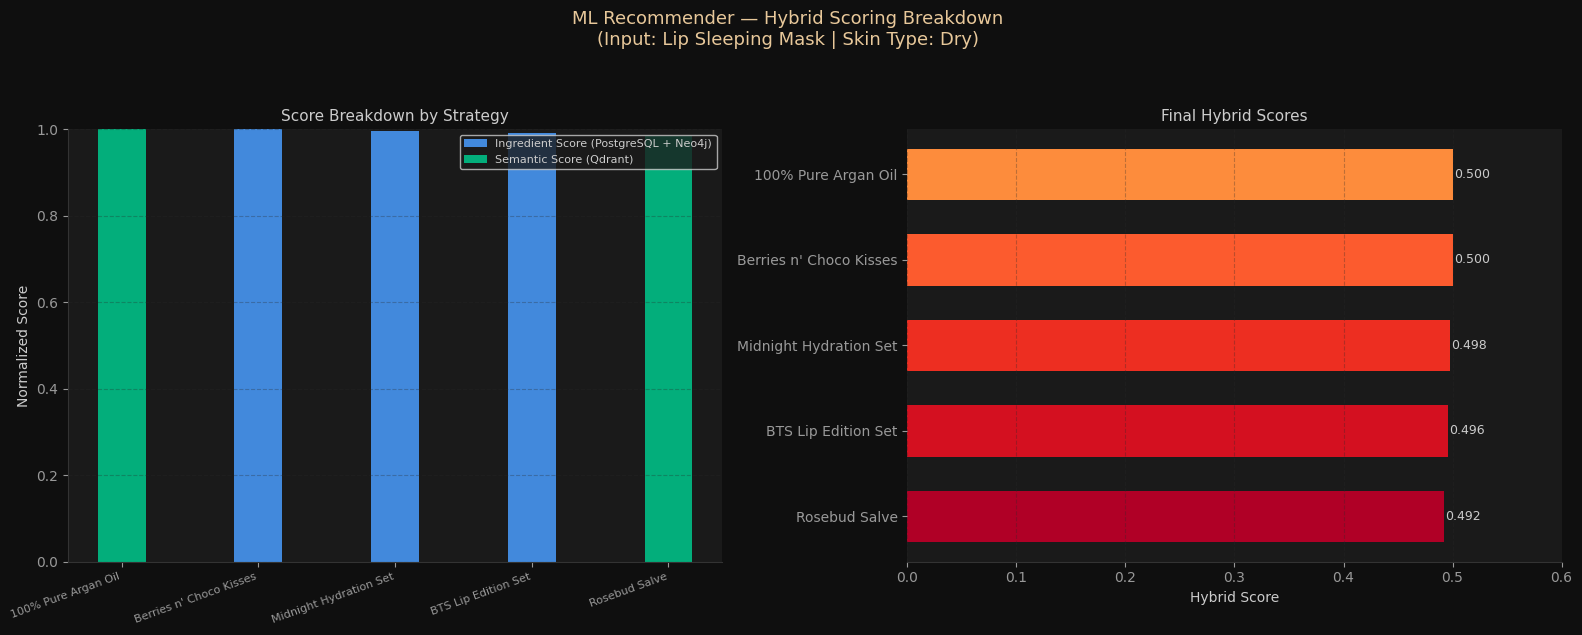

In [7]:
# Show recommendation scores visually
recommend_data = {
    "Product": [
        "100% Pure Argan Oil",
        "Berries n' Choco Kisses",
        "Midnight Hydration Set",
        "BTS Lip Edition Set",
        "Rosebud Salve"
    ],
    "Ingredient Score": [0.00, 1.00, 0.995, 0.991, 0.00],
    "Semantic Score":   [1.00, 0.00, 0.00,  0.00,  0.984],
    "Hybrid Score":     [0.500, 0.500, 0.498, 0.496, 0.492]
}
df_rec = pd.DataFrame(recommend_data)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#0f0f0f")
fig.suptitle("ML Recommender — Hybrid Scoring Breakdown\n(Input: Lip Sleeping Mask | Skin Type: Dry)",
             fontsize=13, color="#e8c89a", y=1.05)

# Stacked bar — score breakdown
x = np.arange(len(df_rec))
width = 0.35
axes[0].bar(x, df_rec["Ingredient Score"], width, 
            label="Ingredient Score (PostgreSQL + Neo4j)", 
            color="#4a9eff", alpha=0.85)
axes[0].bar(x, df_rec["Semantic Score"], width,
            bottom=df_rec["Ingredient Score"],
            label="Semantic Score (Qdrant)", 
            color="#00c98d", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_rec["Product"], rotation=20, ha='right', fontsize=8)
axes[0].set_title("Score Breakdown by Strategy", color="#cccccc", fontsize=11)
axes[0].set_ylabel("Normalized Score")
axes[0].legend(fontsize=8, loc="upper right")
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# Final hybrid scores
colors = plt.cm.YlOrRd(np.linspace(0.5, 0.9, len(df_rec)))[::-1]
bars = axes[1].barh(df_rec["Product"][::-1], 
                    df_rec["Hybrid Score"][::-1],
                    color=colors, height=0.6)
for bar, val in zip(bars, df_rec["Hybrid Score"][::-1]):
    axes[1].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                 f"{val:.3f}", va='center', color="#cccccc", fontsize=9)
axes[1].set_title("Final Hybrid Scores", color="#cccccc", fontsize=11)
axes[1].set_xlabel("Hybrid Score")
axes[1].set_xlim(0, 0.6)
axes[1].grid(axis='x', alpha=0.3)
axes[1].spines[['top','right','left']].set_visible(False)

plt.tight_layout()
plt.savefig("../reports/06_recommender.png", dpi=150, bbox_inches="tight",
            facecolor="#0f0f0f")
plt.show()

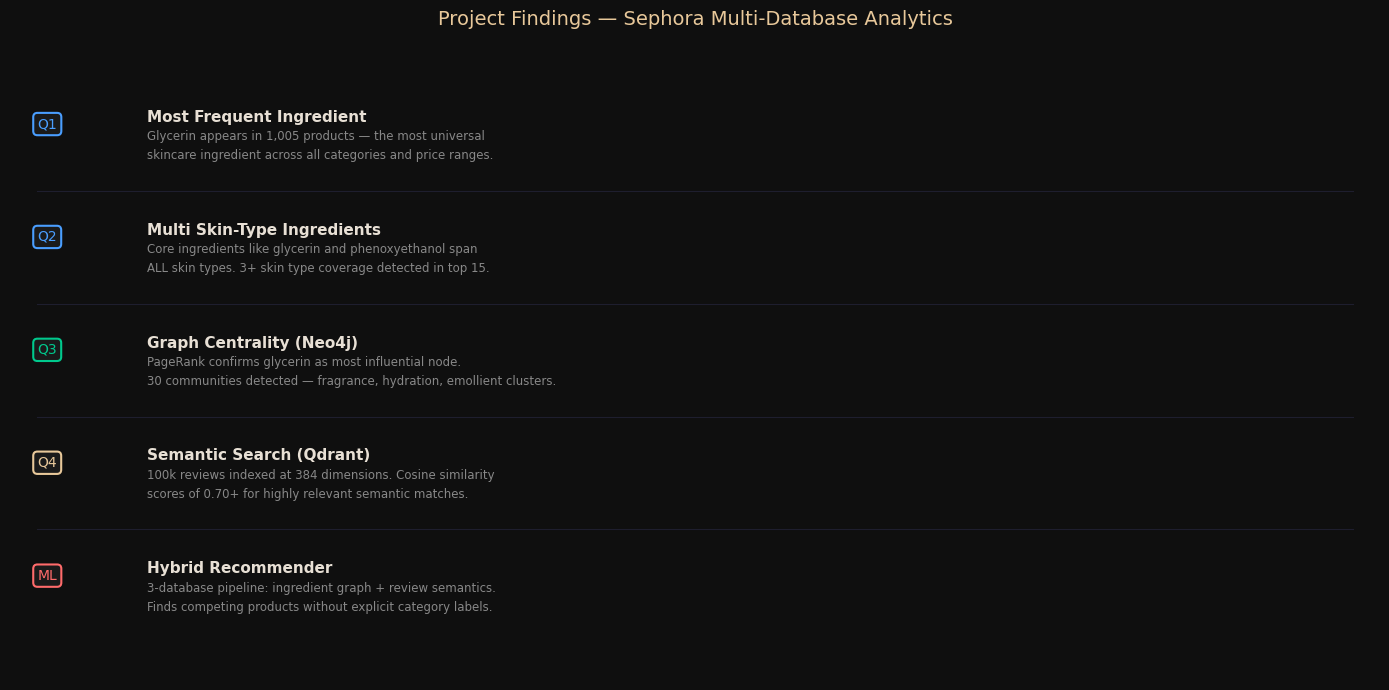

In [9]:
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor("#0f0f0f")
ax.set_facecolor("#0f0f0f")
ax.axis("off")

findings = [
    ("Q1", "Most Frequent Ingredient",
     "Glycerin appears in 1,005 products — the most universal\nskincare ingredient across all categories and price ranges."),
    ("Q2", "Multi Skin-Type Ingredients",
     "Core ingredients like glycerin and phenoxyethanol span\nALL skin types. 3+ skin type coverage detected in top 15."),
    ("Q3", "Graph Centrality (Neo4j)",
     "PageRank confirms glycerin as most influential node.\n30 communities detected — fragrance, hydration, emollient clusters."),
    ("Q4", "Semantic Search (Qdrant)",
     "100k reviews indexed at 384 dimensions. Cosine similarity\nscores of 0.70+ for highly relevant semantic matches."),
    ("ML", "Hybrid Recommender",
     "3-database pipeline: ingredient graph + review semantics.\nFinds competing products without explicit category labels."),
]

colors = ["#4a9eff", "#4a9eff", "#00c98d", "#e8c89a", "#ff6b6b"]

for i, (tag, title, desc) in enumerate(findings):
    y = 0.88 - i * 0.18
    # Tag box
    ax.text(0.02, y, tag, transform=ax.transAxes,
            fontsize=10, color=colors[i],
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#1a1a1a",
                      edgecolor=colors[i], linewidth=1.5))
    # Title
    ax.text(0.10, y + 0.01, title, transform=ax.transAxes,
            fontsize=11, color="#e8e0d5", fontweight="bold")
    # Description
    ax.text(0.10, y - 0.05, desc, transform=ax.transAxes,
            fontsize=8.5, color="#888888", linespacing=1.6)
    # Divider line
    if i < len(findings) - 1:
        ax.axhline(y=y - 0.10, xmin=0.02, xmax=0.98,
           color="#1e1e2e", linewidth=0.8)

ax.set_title("Project Findings — Sephora Multi-Database Analytics",
             fontsize=14, color="#e8c89a", pad=20)

plt.tight_layout()
plt.savefig("../reports/07_findings_summary.png", dpi=150, bbox_inches="tight",
            facecolor="#0f0f0f")
plt.show()